In [1]:
!pip install facenet-pytorch opencv-python scikit-learn matplotlib joblib ImageHash

In [2]:
from google.colab import files

uploaded = files.upload()

Saving FaceDetectionDataset.zip to FaceDetectionDataset.zip


In [8]:
import zipfile
import os

zip_path = "FaceDetectionDataset.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("lfw_dataset")

print(os.listdir("lfw_dataset"))

['peopleDevTrain.csv', 'mismatchpairsDevTest.csv', 'lfw-deepfunneled', 'matchpairsDevTest.csv', 'peopleDevTest.csv', 'lfw_readme.csv', 'pairs.csv', 'lfw_allnames.csv', 'mismatchpairsDevTrain.csv', 'people.csv', 'matchpairsDevTrain.csv']


In [9]:
import os
import numpy as np
from PIL import Image
from collections import Counter

import torch
from facenet_pytorch import MTCNN, InceptionResnetV1

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib
import matplotlib.pyplot as plt

DATASET_PATH = "lfw_dataset/lfw-deepfunneled/lfw-deepfunneled"
MIN_IMAGES_PER_PERSON = 20
TEST_SIZE = 0.25
RANDOM_STATE = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
print("Dataset exists:", os.path.exists(DATASET_PATH))
print("Number of folders:", len(os.listdir(DATASET_PATH)))

Using device: cuda
Dataset exists: True
Number of folders: 5749


          DATASET SUMMARY
  Total persons          :  5,749
  Total images           : 13,233
  Persons ≥ 20 images     :     62
  Images in eligible set :  3,023


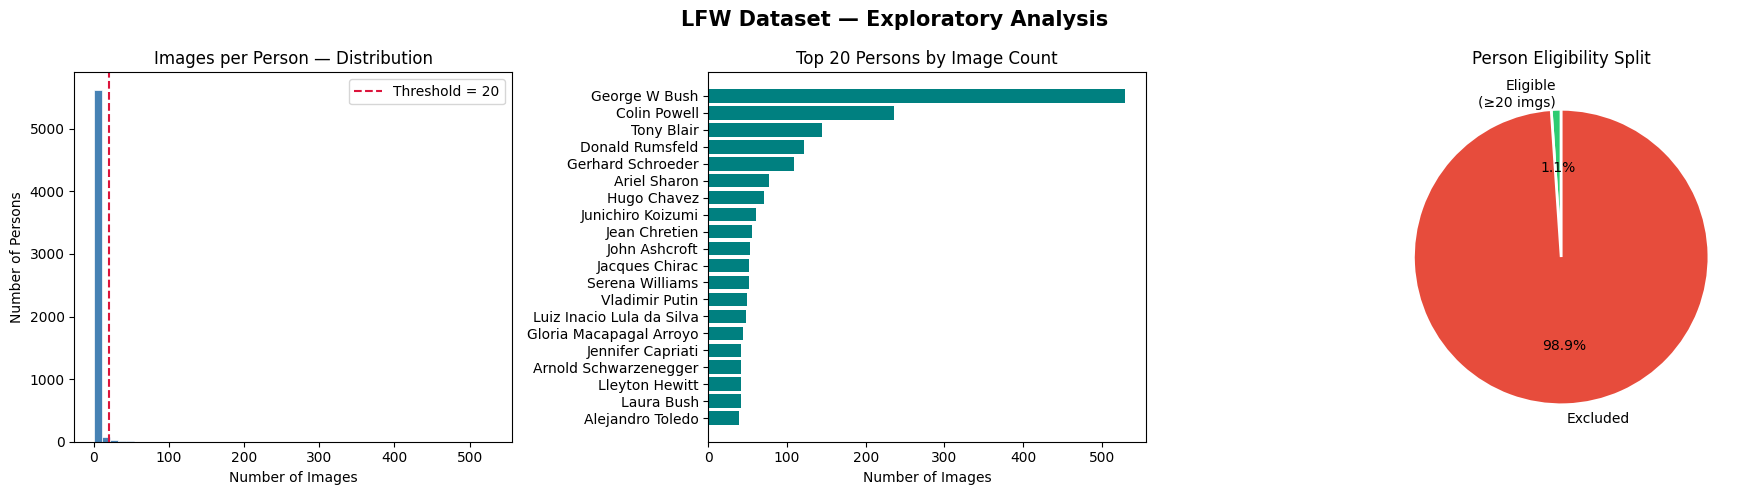

✔ Plot saved: 01_dataset_exploration.png


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

DATASET_PATH = "lfw_dataset/lfw-deepfunneled/lfw-deepfunneled"
MIN_IMAGES_PER_PERSON = 20

# Count images per person
person_image_counts = {}
for person in os.listdir(DATASET_PATH):
    person_dir = os.path.join(DATASET_PATH, person)
    if os.path.isdir(person_dir):
        imgs = [f for f in os.listdir(person_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        person_image_counts[person] = len(imgs)

total_persons  = len(person_image_counts)
total_images   = sum(person_image_counts.values())
eligible       = {k: v for k, v in person_image_counts.items()
                  if v >= MIN_IMAGES_PER_PERSON}

print("=" * 55)
print("          DATASET SUMMARY")
print("=" * 55)
print(f"  Total persons          : {total_persons:>6,}")
print(f"  Total images           : {total_images:>6,}")
print(f"  Persons ≥ {MIN_IMAGES_PER_PERSON} images     : {len(eligible):>6,}")
print(f"  Images in eligible set : {sum(eligible.values()):>6,}")
print("=" * 55)

# Distribution plot
counts = list(person_image_counts.values())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("LFW Dataset — Exploratory Analysis", fontsize=15, fontweight='bold')

# Histogram of image counts
axes[0].hist(counts, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(MIN_IMAGES_PER_PERSON, color='crimson', linestyle='--',
                label=f'Threshold = {MIN_IMAGES_PER_PERSON}')
axes[0].set_title("Images per Person — Distribution")
axes[0].set_xlabel("Number of Images")
axes[0].set_ylabel("Number of Persons")
axes[0].legend()

# Top-20 persons bar chart
top20 = sorted(person_image_counts.items(), key=lambda x: x[1], reverse=True)[:20]
names, img_counts = zip(*top20)
short_names = [n.replace('_', ' ') for n in names]
axes[1].barh(short_names[::-1], img_counts[::-1], color='teal')
axes[1].set_title("Top 20 Persons by Image Count")
axes[1].set_xlabel("Number of Images")

# Eligible vs Excluded pie
axes[2].pie(
    [len(eligible), total_persons - len(eligible)],
    labels=[f'Eligible\n(≥{MIN_IMAGES_PER_PERSON} imgs)', 'Excluded'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[2].set_title("Person Eligibility Split")

plt.tight_layout()
plt.savefig("01_dataset_exploration.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Plot saved: 01_dataset_exploration.png")

Total images before cleaning : 3,023
Total persons before cleaning: 62


Cleaning images: 100%|██████████| 3023/3023 [00:09<00:00, 325.79it/s]



          CLEANING REPORT  (pHash)
  Original images           :  3,023
  Corrupted images removed  :      0
  Duplicate images removed  :      2
  ─────────────────────────────────────
  Clean images remaining    :  3,021
  Persons after cleaning    :     62
  Images after cleaning     :  3,021

Duplicate paths removed (2):
✗ George_W_Bush_0194.jpg
✗ Serena_Williams_0016.jpg


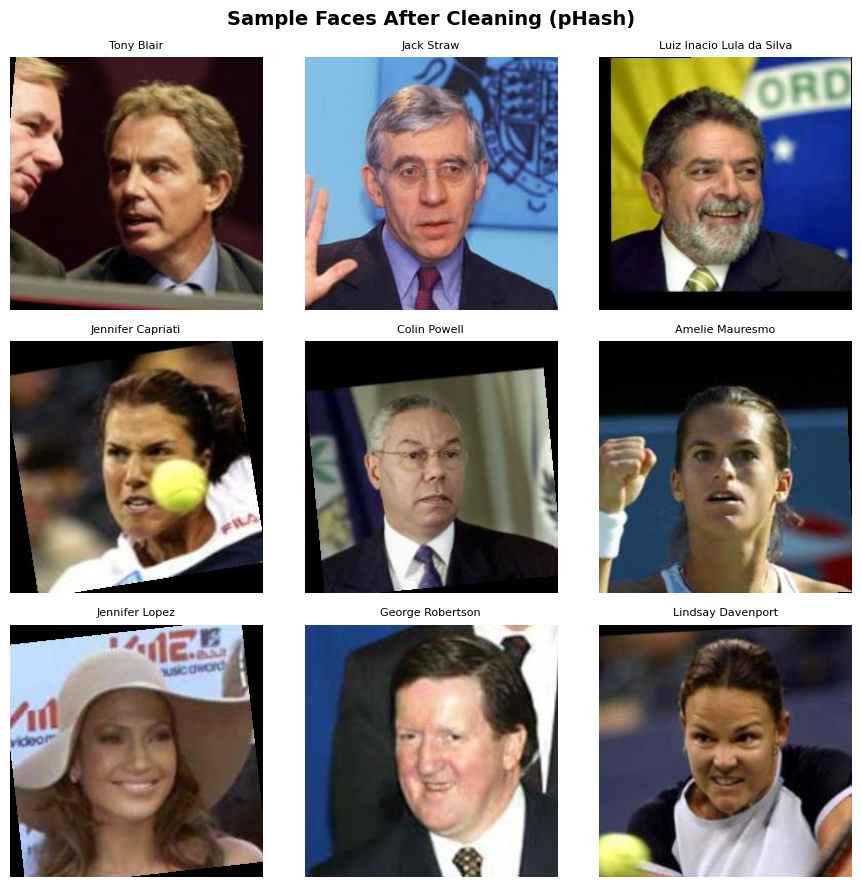


✔ Plot saved: 02_sample_faces.png


In [12]:
# Required imports for this cell
import os
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict
from tqdm import tqdm
import imagehash

# Parameters
HASH_SIZE = 8

# Build image_paths & labels from eligible dict
image_paths = []
labels = []

for person, count in eligible.items():
    person_dir = os.path.join(DATASET_PATH, person)

    for fname in sorted(os.listdir(person_dir)):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(person_dir, fname))
            labels.append(person)

print(f"Total images before cleaning : {len(image_paths):,}")
print(f"Total persons before cleaning: {len(eligible):,}")


# pHash-based duplicate + corrupted removal
def remove_duplicate_images(image_paths, labels, hash_size=8):
    """
    Scans all images using perceptual hashing.
    - Corrupted/unreadable images are removed.
    - Exact pHash duplicate images are removed.
    """

    seen_hashes = {}
    unique_paths = []
    unique_labels = []
    duplicate_paths = []
    corrupted_paths = []

    for path, label in tqdm(
        zip(image_paths, labels),
        total=len(image_paths),
        desc="Cleaning images"
    ):
        try:
            img = Image.open(path).convert("RGB")
            img_hash = imagehash.phash(img, hash_size=hash_size)

            if img_hash in seen_hashes:
                duplicate_paths.append(path)
            else:
                seen_hashes[img_hash] = path
                unique_paths.append(path)
                unique_labels.append(label)

        except Exception:
            corrupted_paths.append(path)

    return unique_paths, unique_labels, duplicate_paths, corrupted_paths


# Run cleaning
(
    image_paths_clean,
    labels_clean,
    duplicate_paths,
    corrupted_paths
) = remove_duplicate_images(image_paths, labels, HASH_SIZE)


# Rebuild valid_dataset dict from clean lists
valid_dataset = defaultdict(list)

for path, label in zip(image_paths_clean, labels_clean):
    valid_dataset[label].append(path)


# Re-apply MIN_IMAGES_PER_PERSON threshold after cleaning
valid_dataset = {
    person: paths
    for person, paths in valid_dataset.items()
    if len(paths) >= MIN_IMAGES_PER_PERSON
}

total_clean = sum(len(v) for v in valid_dataset.values())


# Cleaning report
print("\n" + "=" * 55)
print("          CLEANING REPORT  (pHash)")
print("=" * 55)
print(f"  Original images           : {len(image_paths):>6,}")
print(f"  Corrupted images removed  : {len(corrupted_paths):>6,}")
print(f"  Duplicate images removed  : {len(duplicate_paths):>6,}")
print("  ─────────────────────────────────────")
print(f"  Clean images remaining    : {len(image_paths_clean):>6,}")
print(f"  Persons after cleaning    : {len(valid_dataset):>6,}")
print(f"  Images after cleaning     : {total_clean:>6,}")
print("=" * 55)


# Optional: print removed duplicate paths
if duplicate_paths:
    print(f"\nDuplicate paths removed ({len(duplicate_paths)}):")
    for p in duplicate_paths[:20]:
        print(f"✗ {os.path.basename(p)}")

    if len(duplicate_paths) > 20:
        print(f"... and {len(duplicate_paths) - 20} more")


# Sample grid of clean faces
sample_persons = list(valid_dataset.keys())[:9]

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
fig.suptitle("Sample Faces After Cleaning (pHash)", fontsize=14, fontweight='bold')

for ax, person in zip(axes.flat, sample_persons):
    img_path = valid_dataset[person][0]
    img = Image.open(img_path).convert("RGB")

    ax.imshow(img)
    ax.set_title(person.replace("_", " "), fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig("02_sample_faces.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✔ Plot saved: 02_sample_faces.png")

          EMBEDDING EXTRACTION
  Device      : cuda
  Image size  : 160×160 (FaceNet requirement)
  Augmentation: ON  (train split only)



  0%|          | 0.00/107M [00:00<?, ?B/s]

✔ MTCNN loaded           — face detector + aligner
✔ InceptionResnetV1 loaded — VGGFace2 pre-trained
  Embedding dimension    : 512

  Train paths : 2,416
  Test  paths : 605
  After aug   : ~12,080 train embeddings

───────────────────────────────────────────────────────


Extracting [TRAIN + AUG]: 100%|██████████| 2416/2416 [13:15<00:00,  3.04it/s]


  ✔ Done — 12,080 embeddings  | 0 failed detections


Extracting [TEST]: 100%|██████████| 605/605 [00:41<00:00, 14.56it/s]


  ✔ Done — 605 embeddings  | 0 failed detections

  Total time : 837s  (13.9 min)

          EMBEDDING SUMMARY
  Train embeddings : (12080, 512)
  Test  embeddings : (605, 512)
  Embedding dim    : 512  (L2-normalized)
  Saved to         : embeddings.npz


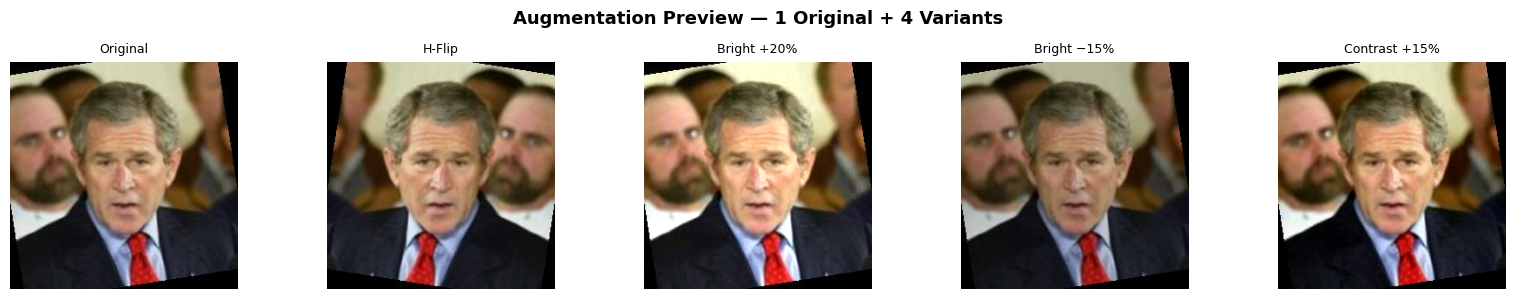

✔ Plot saved: 03_augmentation_preview.png

Running t-SNE on top 12 identities (6538 embeddings) …


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


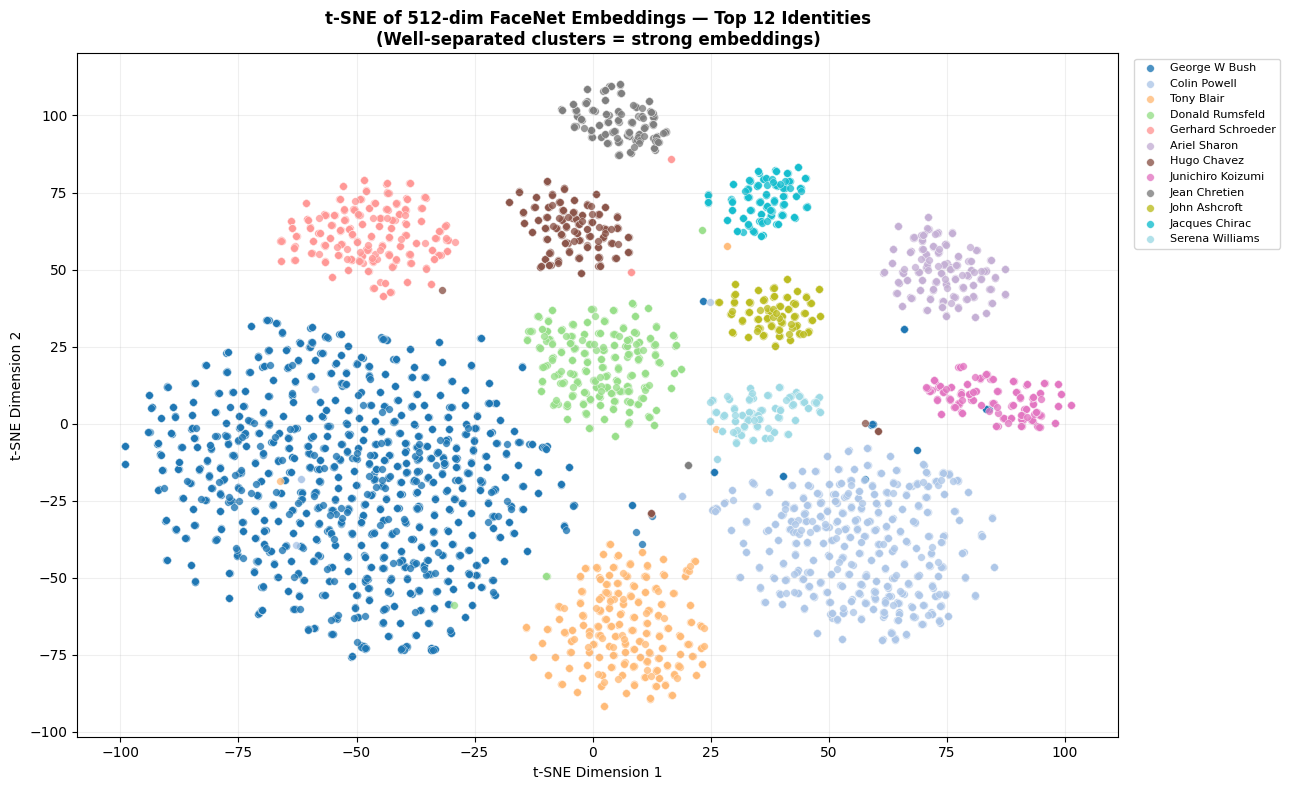

✔ Plot saved: 04_tsne_embeddings.png


In [13]:
# FaceNet Embedding Extraction
# MTCNN auto-resizes to 160×160
# Augmentation on train split only
# Saves embeddings.npz for classifier
import os
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from PIL                 import Image, ImageEnhance
from tqdm                import tqdm
from collections         import Counter
from facenet_pytorch     import MTCNN, InceptionResnetV1
from sklearn.manifold    import TSNE
from sklearn.model_selection import train_test_split

# Config
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE       = 160          # FaceNet requirement
EMBEDDING_FILE = "embeddings.npz"
AUGMENT        = True

print("=" * 55)
print("          EMBEDDING EXTRACTION")
print("=" * 55)
print(f"  Device      : {DEVICE}")
print(f"  Image size  : {IMG_SIZE}×{IMG_SIZE} (FaceNet requirement)")
print(f"  Augmentation: {'ON  (train split only)' if AUGMENT else 'OFF'}")
print("=" * 55 + "\n")

# Load models
mtcnn  = MTCNN(
    image_size     = IMG_SIZE,    # auto-resizes detected face to 160×160
    margin         = 14,          # pixels of context around face
    keep_all       = False,       # keep only the most prominent face
    min_face_size  = 20,
    device         = DEVICE
)

resnet = InceptionResnetV1(
    pretrained = 'vggface2'       # pre-trained on 3.3M VGGFace2 images
).eval().to(DEVICE)

# Freeze all weights - we use FaceNet as a fixed feature extractor
for param in resnet.parameters():
    param.requires_grad = False

print(f"✔ MTCNN loaded           — face detector + aligner")
print(f"✔ InceptionResnetV1 loaded — VGGFace2 pre-trained")
print(f"  Embedding dimension    : 512\n")

# Augmentation helpers
def augment_image(pil_img):
    """
    Returns a list of augmented PIL images for one input.
    All transforms are face-safe (no rotation, no cropping).
    Train split only — never apply to test images.
    """
    augmented = []

    # 1) Horizontal flip
    augmented.append(pil_img.transpose(Image.FLIP_LEFT_RIGHT))

    # 2) Slight brightness boost (+20%)
    augmented.append(
        ImageEnhance.Brightness(pil_img).enhance(1.20)
    )

    # 3) Slight brightness drop (−15%)
    augmented.append(
        ImageEnhance.Brightness(pil_img).enhance(0.85)
    )

    # 4) Contrast boost (+15%)
    augmented.append(
        ImageEnhance.Contrast(pil_img).enhance(1.15)
    )

    return augmented   # 4 augmented versions per original image


# Build label maps
all_persons = sorted(valid_dataset.keys())
label2idx   = {p: i for i, p in enumerate(all_persons)}
idx2label   = {i: p for p, i in label2idx.items()}

# Flat lists for train/test split
all_paths  = []
all_labels = []
for person, paths in valid_dataset.items():
    for p in paths:
        all_paths.append(p)
        all_labels.append(label2idx[person])

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

# Train / Test path split BEFORE extraction
# Split paths first so augmentation is ONLY applied to train
paths_train, paths_test, y_train_paths, y_test_paths = train_test_split(
    all_paths, all_labels,
    test_size    = 0.20,
    random_state = 42,
    stratify     = all_labels
)

print(f"  Train paths : {len(paths_train):,}")
print(f"  Test  paths : {len(paths_test):,}")
if AUGMENT:
    print(f"  After aug   : ~{len(paths_train)*5:,} train embeddings\n")

# Core extraction function
def extract_embeddings(paths, labels, augment=False, split_name=""):
    """
    For each image:
      1. Open PIL image
      2. MTCNN detects + aligns face → resized to 160×160 tensor
      3. FaceNet encodes → 512-dim embedding
      4. If augment=True, repeat for 4 augmented versions
    """
    embeddings_out = []
    labels_out     = []
    failed         = 0

    desc = f"Extracting [{split_name}]"
    for path, label in tqdm(zip(paths, labels),
                            total=len(paths), desc=desc):
        try:
            pil_img = Image.open(path).convert("RGB")
        except Exception:
            failed += 1
            continue

        # Build list of images to process (original + augmented)
        imgs_to_process = [pil_img]
        if augment:
            imgs_to_process += augment_image(pil_img)

        for img in imgs_to_process:
            try:
                with torch.no_grad():
                    # MTCNN: detect face → align → resize to 160×160
                    face_tensor = mtcnn(img)
                    if face_tensor is None:
                        failed += 1
                        continue

                    # FaceNet: 160×160 → 512-dim L2-normalized embedding
                    face_batch = face_tensor.unsqueeze(0).to(DEVICE)
                    embedding  = resnet(face_batch).cpu().numpy()[0]

                embeddings_out.append(embedding)
                labels_out.append(label)

            except Exception:
                failed += 1
                continue

    print(f"  ✔ Done — {len(embeddings_out):,} embeddings  "
          f"| {failed} failed detections")
    return np.array(embeddings_out), np.array(labels_out)


# Extract train (with augmentation) & test
print("─" * 55)
t0 = time.time()

X_train_emb, y_train_emb = extract_embeddings(
    paths_train, y_train_paths,
    augment    = AUGMENT,
    split_name = "TRAIN + AUG"
)

X_test_emb, y_test_emb = extract_embeddings(
    paths_test, y_test_paths,
    augment    = False,
    split_name = "TEST"
)

elapsed = time.time() - t0
print(f"\n  Total time : {elapsed:.0f}s  ({elapsed/60:.1f} min)")

# Save embeddings
np.savez_compressed(
    EMBEDDING_FILE,
    X_train    = X_train_emb,
    y_train    = y_train_emb,
    X_test     = X_test_emb,
    y_test     = y_test_emb,
    idx2label  = np.array([idx2label[i] for i in range(len(idx2label))])
)

print("\n" + "=" * 55)
print("          EMBEDDING SUMMARY")
print("=" * 55)
print(f"  Train embeddings : {X_train_emb.shape}")
print(f"  Test  embeddings : {X_test_emb.shape}")
print(f"  Embedding dim    : 512  (L2-normalized)")
print(f"  Saved to         : {EMBEDDING_FILE}")
print("=" * 55)

# Augmentation impact chart
if AUGMENT:
    fig, axes = plt.subplots(1, 5, figsize=(16, 3))
    fig.suptitle("Augmentation Preview — 1 Original + 4 Variants",
                 fontsize=13, fontweight='bold')

    sample_path   = paths_train[0]
    sample_pil    = Image.open(sample_path).convert("RGB")
    aug_variants  = augment_image(sample_pil)
    aug_titles    = ["Original", "H-Flip",
                     "Bright +20%", "Bright −15%", "Contrast +15%"]

    for ax, img, title in zip(axes,
                               [sample_pil] + aug_variants,
                               aug_titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig("03_augmentation_preview.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✔ Plot saved: 03_augmentation_preview.png")

# t-SNE embedding visualization (top 12 identities)
TOP_N      = 12
X_all      = np.vstack([X_train_emb, X_test_emb])
y_all      = np.concatenate([y_train_emb, y_test_emb])

top_cls    = [c for c, _ in
              Counter(y_all).most_common(TOP_N)]
mask       = np.isin(y_all, top_cls)
X_sub      = X_all[mask]
y_sub      = y_all[mask]

print(f"\nRunning t-SNE on top {TOP_N} identities "
      f"({X_sub.shape[0]} embeddings) …")
tsne  = TSNE(n_components=2, perplexity=30,
             random_state=42, n_iter=1000)
X_2d  = tsne.fit_transform(X_sub)

colors = cm.tab20(np.linspace(0, 1, TOP_N))
fig, ax = plt.subplots(figsize=(13, 8))

for j, cls_idx in enumerate(top_cls):
    m   = y_sub == cls_idx
    lbl = idx2label[cls_idx].replace('_', ' ')
    ax.scatter(X_2d[m, 0], X_2d[m, 1],
               c=[colors[j]], label=lbl,
               s=30, alpha=0.80, edgecolors='white', linewidths=0.3)

ax.set_title(
    f"t-SNE of 512-dim FaceNet Embeddings — Top {TOP_N} Identities\n"
    f"(Well-separated clusters = strong embeddings)",
    fontsize=12, fontweight='bold'
)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("04_tsne_embeddings.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Plot saved: 04_tsne_embeddings.png")

          CLASSIFIER TRAINING
  Train samples : 12,080  (incl. augmented)
  Test  samples : 605  (original only)
  Embedding dim : 512
  Classes       : 62

  Subtrain : 10,872 | Val : 1,208

Training SVM (RBF) …
  Val  Acc : 0.9959
  Test Acc : 0.9818

Training MLP (512-256) …
  Val  Acc : 0.9950
  Test Acc : 0.9769

  ★  Best model  : SVM (RBF)
     Test Acc    : 0.9818
     Saved to    : face_recognition_model.pkl


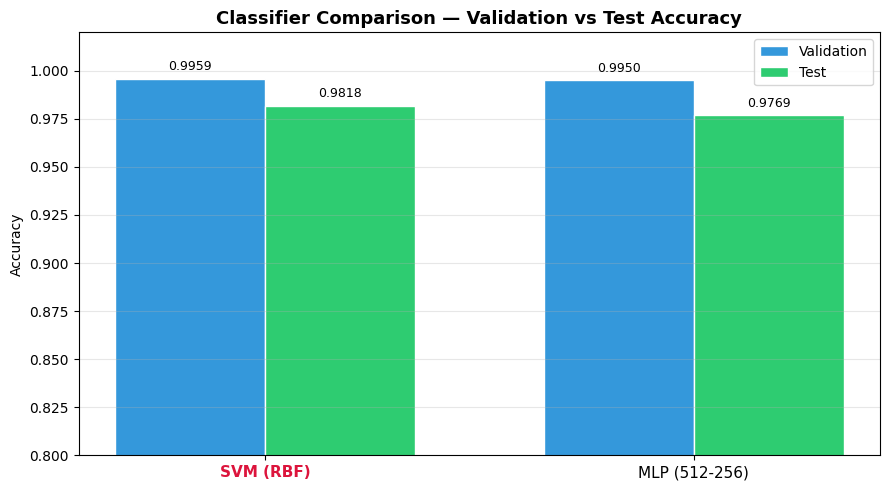

✔ Plot saved: 05_classifier_comparison.png


In [14]:
# Classifier Training
# SVM (RBF) vs MLP — best model saved automatically

import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing  import StandardScaler
from sklearn.svm            import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline       import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics        import accuracy_score

# Load embeddings
data       = np.load(EMBEDDING_FILE, allow_pickle=True)
X_train    = data['X_train']
y_train    = data['y_train']
X_test     = data['X_test']
y_test     = data['y_test']
idx2label  = list(data['idx2label'])

print("=" * 55)
print("          CLASSIFIER TRAINING")
print("=" * 55)
print(f"  Train samples : {X_train.shape[0]:,}  (incl. augmented)")
print(f"  Test  samples : {X_test.shape[0]:,}  (original only)")
print(f"  Embedding dim : {X_train.shape[1]}")
print(f"  Classes       : {len(np.unique(y_train))}")
print("=" * 55 + "\n")

# Validation split from train
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size    = 0.10,
    random_state = 42,
    stratify     = y_train
)
print(f"  Subtrain : {len(X_tr):,} | Val : {len(X_val):,}\n")

# Define classifiers
classifiers = {
    "SVM (RBF)": make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', C=10, gamma='scale',
            probability=True, random_state=42)
    ),
    "MLP (512-256)": make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes = (512, 256),
            activation         = 'relu',
            max_iter           = 300,
            random_state       = 42,
            early_stopping     = True,
            validation_fraction= 0.10,
            n_iter_no_change   = 15,
            verbose            = False
        )
    ),
}

# Train & evaluate all classifiers
results = {}

for name, pipeline in classifiers.items():
    print(f"Training {name} …")
    pipeline.fit(X_tr, y_tr)

    val_acc  = accuracy_score(y_val,  pipeline.predict(X_val))
    test_acc = accuracy_score(y_test, pipeline.predict(X_test))

    results[name] = {
        "pipeline" : pipeline,
        "val_acc"  : val_acc,
        "test_acc" : test_acc,
    }
    print(f"  Val  Acc : {val_acc:.4f}")
    print(f"  Test Acc : {test_acc:.4f}\n")

# Pick best & save
best_name  = max(results, key=lambda k: results[k]['test_acc'])
best_model = results[best_name]['pipeline']
best_acc   = results[best_name]['test_acc']

joblib.dump(best_model, "face_recognition_model.pkl")

print("=" * 55)
print(f"  ★  Best model  : {best_name}")
print(f"     Test Acc    : {best_acc:.4f}")
print(f"     Saved to    : face_recognition_model.pkl")
print("=" * 55)

# Comparison bar chart
names     = list(results.keys())
val_accs  = [results[n]['val_acc']  for n in names]
test_accs = [results[n]['test_acc'] for n in names]

x     = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, val_accs,  width,
            label='Validation', color='#3498db', edgecolor='white')
b2 = ax.bar(x + width/2, test_accs, width,
            label='Test',       color='#2ecc71', edgecolor='white')

ax.set_title("Classifier Comparison — Validation vs Test Accuracy",
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel("Accuracy")
ax.set_ylim(0.80, 1.02)
ax.legend(fontsize=10)
ax.bar_label(b1, fmt='%.4f', padding=4, fontsize=9)
ax.bar_label(b2, fmt='%.4f', padding=4, fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Highlight best model
ax.get_xticklabels()[names.index(best_name)].set_color('crimson')
ax.get_xticklabels()[names.index(best_name)].set_fontweight('bold')

plt.tight_layout()
plt.savefig("05_classifier_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Plot saved: 05_classifier_comparison.png")

  FULL CLASSIFICATION REPORT  (SVM (RBF))
                           precision    recall  f1-score   support

         Alejandro Toledo       1.00      1.00      1.00         8
             Alvaro Uribe       1.00      1.00      1.00         7
          Amelie Mauresmo       1.00      1.00      1.00         4
             Andre Agassi       1.00      1.00      1.00         7
           Angelina Jolie       1.00      1.00      1.00         4
             Ariel Sharon       1.00      1.00      1.00        16
    Arnold Schwarzenegger       1.00      1.00      1.00         9
     Atal Bihari Vajpayee       1.00      1.00      1.00         5
             Bill Clinton       1.00      1.00      1.00         6
             Carlos Menem       1.00      1.00      1.00         4
             Colin Powell       1.00      0.96      0.98        47
            David Beckham       1.00      1.00      1.00         6
          Donald Rumsfeld       1.00      1.00      1.00        24
         George Rob

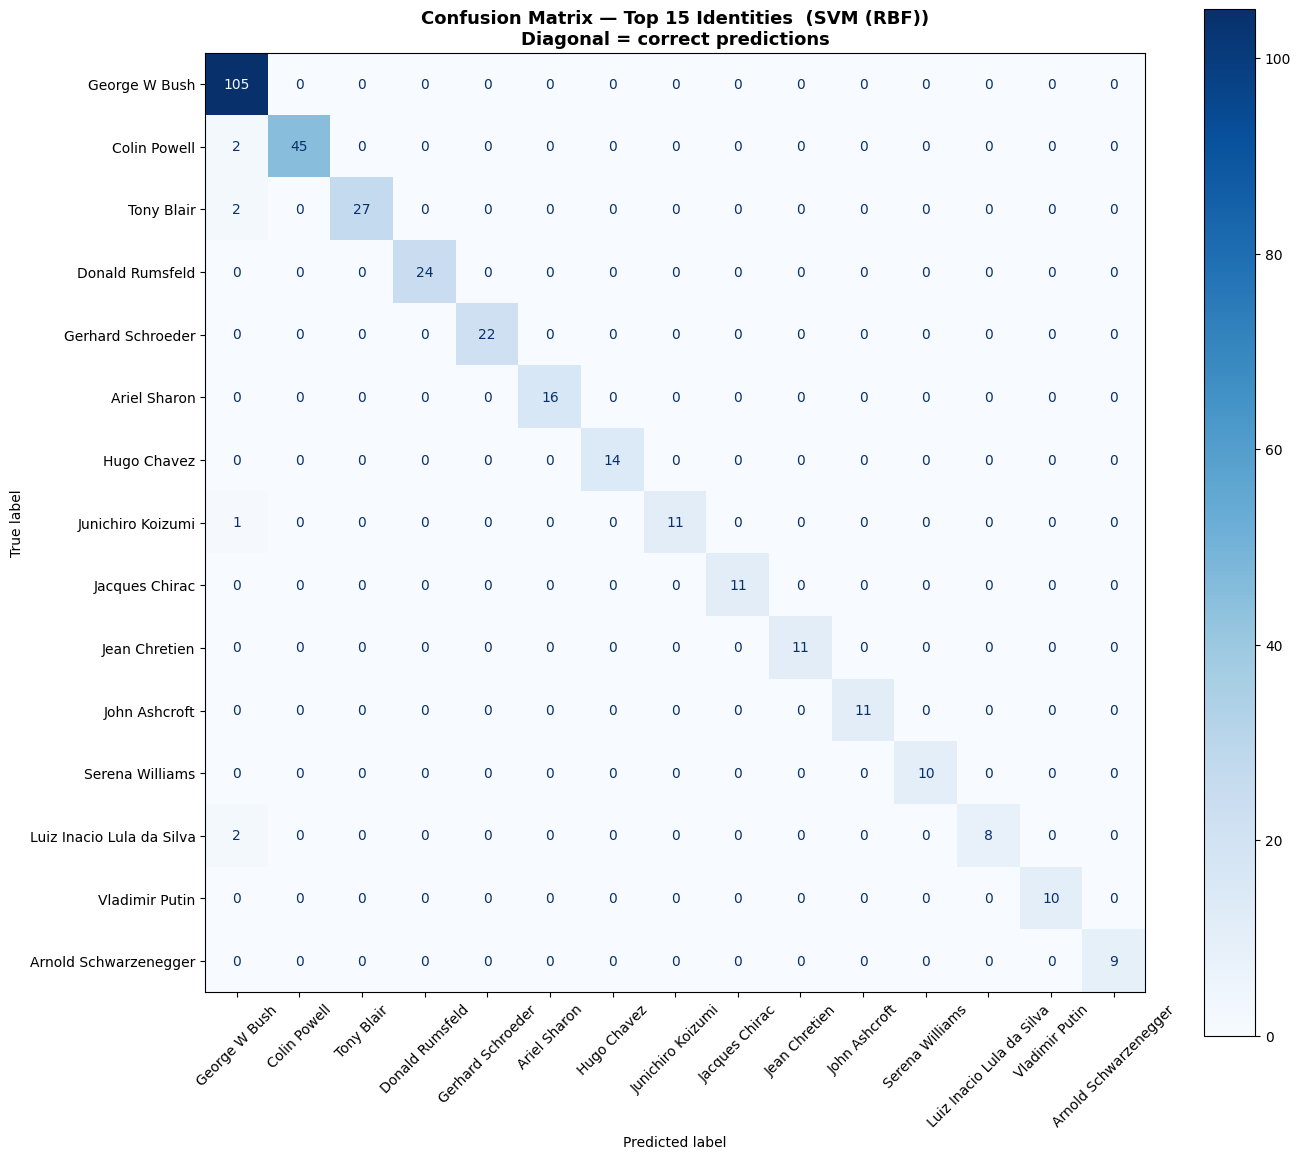

✔ Plot saved: 06_confusion_matrix.png


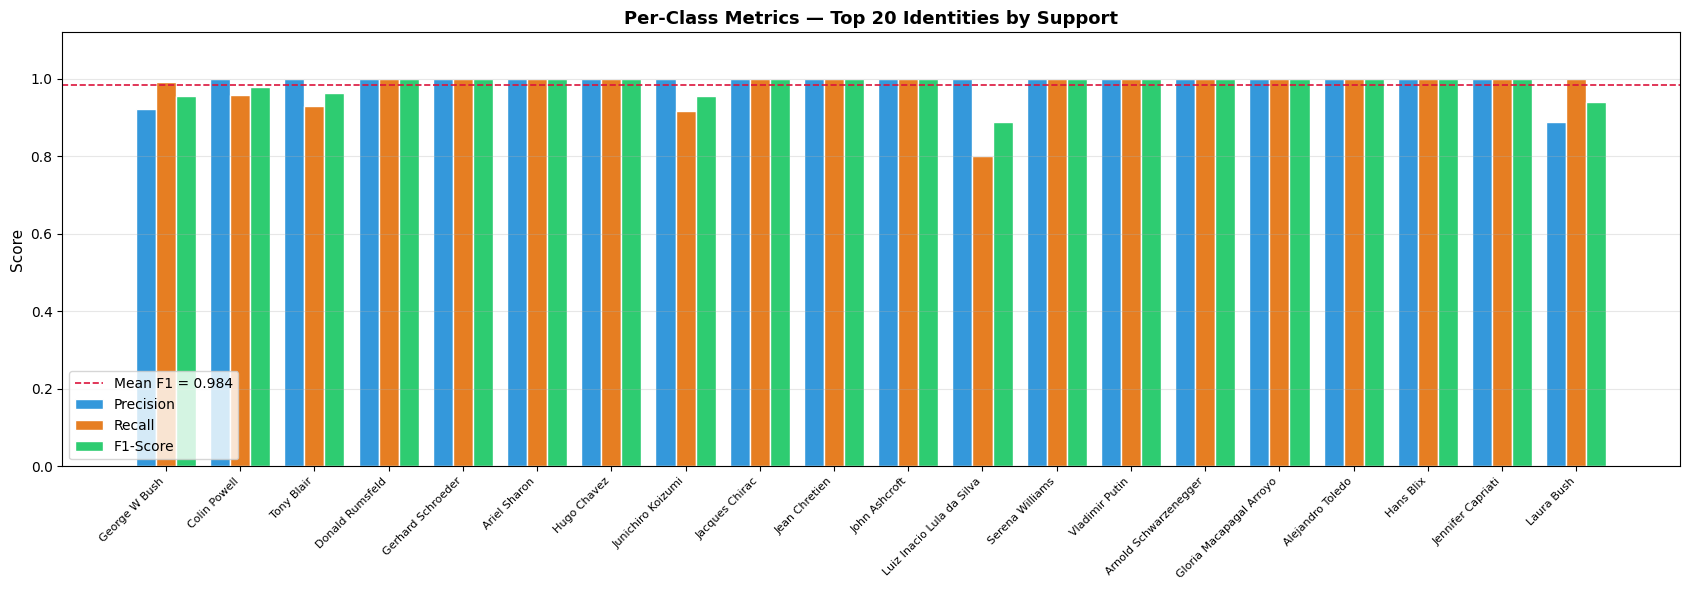

✔ Plot saved: 07_per_class_metrics.png


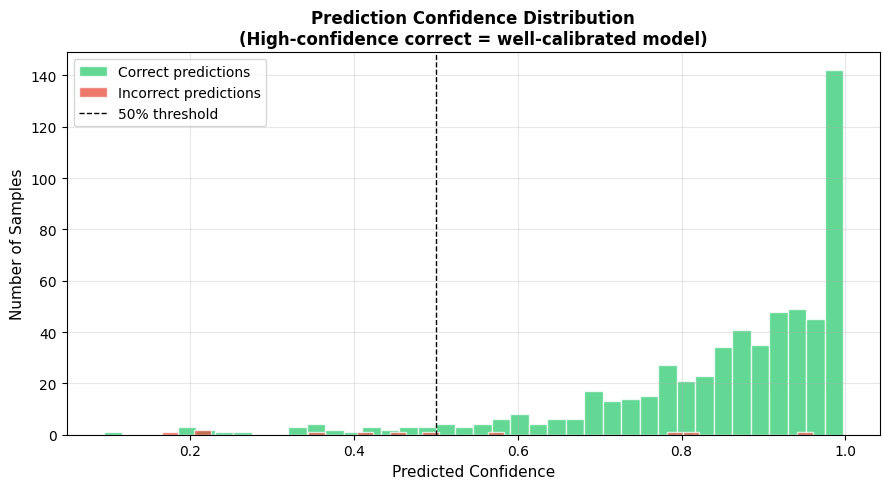

✔ Plot saved: 08_confidence_distribution.png

             FINAL EVALUATION SUMMARY   
  Model              : SVM (RBF)
  Test Accuracy      : 0.9818  (98.18%)
  ─────────────────────────────────────────
  Macro  Precision   : 0.9949
  Macro  Recall      : 0.9847
  Macro  F1-Score    : 0.9885
  ─────────────────────────────────────────
  Weighted Precision : 0.9833
  Weighted Recall    : 0.9818
  Weighted F1-Score  : 0.9814


In [15]:
# Full Evaluation
# Confusion matrix, per-class metrics, final summary

import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from collections import Counter

# Reload if needed
# best_model and X_test / y_test
# If restarted, uncomment:
# data      = np.load("embeddings.npz", allow_pickle=True)
# X_test    = data['X_test'];  y_test = data['y_test']
# idx2label = list(data['idx2label'])
# best_model = joblib.load("face_recognition_model.pkl")

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

# Human-readable names for report
names_test = [idx2label[i].replace('_', ' ') for i in y_test]
names_pred = [idx2label[i].replace('_', ' ') for i in y_pred]

# Classification Report
print("=" * 55)
print(f"  FULL CLASSIFICATION REPORT  ({best_name})")
print("=" * 55)
print(classification_report(names_test, names_pred, zero_division=0))

# Confusion Matrix - top 15 classes
TOP_CM = 15
top_idx   = [c for c, _ in Counter(y_test).most_common(TOP_CM)]
top_names = [idx2label[i].replace('_', ' ') for i in top_idx]

mask_cm = np.isin(y_test, top_idx)
cm      = confusion_matrix(y_test[mask_cm], y_pred[mask_cm],
                           labels=top_idx)

fig, ax = plt.subplots(figsize=(14, 12))
disp    = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=top_names)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45,
          cmap='Blues', values_format='d')
ax.set_title(
    f"Confusion Matrix — Top {TOP_CM} Identities  ({best_name})\n"
    f"Diagonal = correct predictions",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig("06_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Plot saved: 06_confusion_matrix.png")

# Per-class Precision / Recall / F1
report_dict = classification_report(
    y_test, y_pred, output_dict=True, zero_division=0
)

# Top-20 classes by support
top20 = sorted(
    [(int(k), v) for k, v in report_dict.items() if k.isdigit()],
    key    = lambda x: x[1]['support'],
    reverse= True
)[:20]

class_names_20 = [idx2label[k].replace('_', ' ')  for k, _ in top20]
precisions_20  = [v['precision'] for _, v in top20]
recalls_20     = [v['recall']    for _, v in top20]
f1_scores_20   = [v['f1-score']  for _, v in top20]

x = np.arange(len(class_names_20))
w = 0.27

fig, ax = plt.subplots(figsize=(17, 6))
ax.bar(x - w, precisions_20, w, label='Precision', color='#3498db', edgecolor='white')
ax.bar(x,     recalls_20,    w, label='Recall',    color='#e67e22', edgecolor='white')
ax.bar(x + w, f1_scores_20,  w, label='F1-Score',  color='#2ecc71', edgecolor='white')

ax.axhline(np.mean(f1_scores_20), color='crimson',
           linestyle='--', linewidth=1.2,
           label=f'Mean F1 = {np.mean(f1_scores_20):.3f}')

ax.set_xticks(x)
ax.set_xticklabels(class_names_20, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title("Per-Class Metrics — Top 20 Identities by Support",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("07_per_class_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Plot saved: 07_per_class_metrics.png")

# Confidence distribution chart
correct_conf   = y_proba[np.arange(len(y_test)),
                          y_pred][y_pred == y_test]
incorrect_conf = y_proba[np.arange(len(y_test)),
                          y_pred][y_pred != y_test]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(correct_conf,   bins=40, alpha=0.75,
        color='#2ecc71', label='Correct predictions',  edgecolor='white')
ax.hist(incorrect_conf, bins=40, alpha=0.75,
        color='#e74c3c', label='Incorrect predictions', edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='50% threshold')
ax.set_xlabel("Predicted Confidence", fontsize=11)
ax.set_ylabel("Number of Samples",    fontsize=11)
ax.set_title("Prediction Confidence Distribution\n"
             "(High-confidence correct = well-calibrated model)",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("08_confidence_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Plot saved: 08_confidence_distribution.png")

# Final summary card
macro    = report_dict['macro avg']
weighted = report_dict['weighted avg']
acc      = accuracy_score(y_test, y_pred)

print("\n" + "=" * 55)
print("             FINAL EVALUATION SUMMARY   ")
print("=" * 55)
print(f"  Model              : {best_name}")
print(f"  Test Accuracy      : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  ─────────────────────────────────────────")
print(f"  Macro  Precision   : {macro['precision']:.4f}")
print(f"  Macro  Recall      : {macro['recall']:.4f}")
print(f"  Macro  F1-Score    : {macro['f1-score']:.4f}")
print(f"  ─────────────────────────────────────────")
print(f"  Weighted Precision : {weighted['precision']:.4f}")
print(f"  Weighted Recall    : {weighted['recall']:.4f}")
print(f"  Weighted F1-Score  : {weighted['f1-score']:.4f}")
print("=" * 55)

Ground truth : Tony Blair

   FACE RECOGNITION — TOP PREDICTIONS
  1. Tony Blair                    97.6%  ███████████████████ ← best match
  2. Michael Bloomberg              0.1%  
  3. George W Bush                  0.1%  
  4. Gerhard Schroeder              0.1%  
  5. Colin Powell                   0.1%  


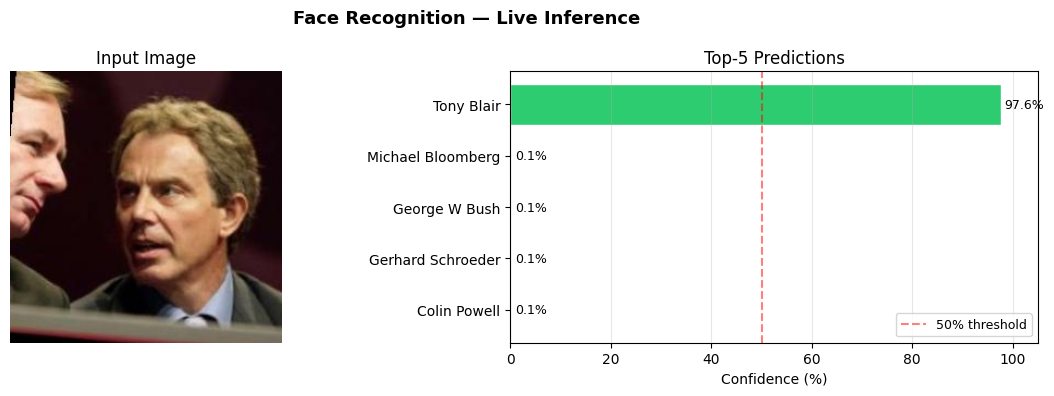

In [16]:
# Live Inference — identify any face image


def predict_identity(image_path, model, mtcnn, resnet,
                     idx2label, device=DEVICE, top_k=5):
    """
    Full pipeline: image → MTCNN align → FaceNet embed → classify.
    Shows top-K predictions with confidence bars.
    """
    pil_img = Image.open(image_path).convert("RGB")

    with torch.no_grad():
        face_tensor = mtcnn(pil_img)

    if face_tensor is None:
        print("No face detected. Try a clearer image.")
        return None

    with torch.no_grad():
        emb   = resnet(face_tensor.unsqueeze(0).to(device))
        emb   = emb.cpu().numpy()

    proba      = model.predict_proba(emb)[0]
    top_k_idx  = np.argsort(proba)[::-1][:top_k]
    top_names  = [idx2label[i].replace('_', ' ') for i in top_k_idx]
    top_confs  = [proba[i] * 100                  for i in top_k_idx]

    # Console output
    print("\n" + "=" * 48)
    print("   FACE RECOGNITION — TOP PREDICTIONS")
    print("=" * 48)
    for rank, (name, conf) in enumerate(zip(top_names, top_confs), 1):
        bar   = "█" * int(conf / 5)
        flag  = " ← best match" if rank == 1 else ""
        print(f"  {rank}. {name:<28} {conf:5.1f}%  {bar}{flag}")
    print("=" * 48)

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Face Recognition — Live Inference",
                 fontsize=13, fontweight='bold')

    axes[0].imshow(pil_img)
    axes[0].set_title("Input Image")
    axes[0].axis('off')

    colors_bar = ['#2ecc71' if i == 0 else '#3498db'
                  for i in range(top_k)]
    bars = axes[1].barh(top_names[::-1], top_confs[::-1],
                        color=colors_bar[::-1], edgecolor='white')
    axes[1].set_xlabel("Confidence (%)")
    axes[1].set_xlim(0, 105)
    axes[1].set_title(f"Top-{top_k} Predictions")
    axes[1].axvline(50, color='red', linestyle='--',
                    alpha=0.5, label='50% threshold')
    axes[1].bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
    axes[1].legend(fontsize=9)
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig("09_inference_result.png", dpi=150, bbox_inches='tight')
    plt.show()
    return top_names[0], top_confs[0]

# Run on a sample from the dataset
sample_person = list(valid_dataset.keys())[0]
sample_image  = valid_dataset[sample_person][0]

print(f"Ground truth : {sample_person.replace('_', ' ')}")
predicted, confidence = predict_identity(
    sample_image, best_model, mtcnn, resnet, idx2label
)

In [17]:
# Download all files needed for local VS Code app

from google.colab import files
import shutil, os, numpy as np

# Save idx2label as a separate .npy for the app
data      = np.load("embeddings.npz", allow_pickle=True)
idx2label = list(data['idx2label'])
np.save("idx2label.npy", np.array(idx2label))

print("Downloading model files...\n")
files.download("face_recognition_model.pkl")  # SVM model
files.download("idx2label.npy")               # class names
print("✔ Done! Put both files in your VS Code project folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✔ Done! Put both files in your VS Code project folder.
